# Module 25 · Phát hiện và ước lượng dạng sóng

**Nguồn sách:** Barkat, chương 10, tr. 533 đến 590

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Phát hiện nhị phân đơn giản: $d^2$, $P_D$, $P_F$
🎯 **Phương pháp này trả lời câu hỏi gì?** Tham số phát hiện, ngưỡng, và xác suất phát hiện/báo động giả tính từ công thức đóng của bài toán quy về Ví dụ 5.1 có khớp mô phỏng Monte Carlo trực tiếp trên $Y_1$?

In [2]:
import numpy as np
from scipy import stats, integrate
from scipy.special import i0
rg = np.random.default_rng(25)

E, N0 = 4.0, 1.0
eta = 1.0
simple_d2 = 2*E/N0
report("simple_d2", simple_d2, ".4f")
assert abs(simple_d2 - 8.0) < 1e-9

simple_gamma = (N0/(2*np.sqrt(E)))*np.log(eta) + np.sqrt(E)/2
report("simple_gamma", simple_gamma, ".4f")

simple_PD_theory = stats.norm.sf((simple_gamma - np.sqrt(E))/np.sqrt(N0/2))
simple_PF_theory = stats.norm.sf(simple_gamma/np.sqrt(N0/2))
report("simple_PD_theory", simple_PD_theory, ".4f")
report("simple_PF_theory", simple_PF_theory, ".4f")

n = 300000
Y1_0 = rg.normal(0, np.sqrt(N0/2), n)
Y1_1 = rg.normal(np.sqrt(E), np.sqrt(N0/2), n)
simple_PD_mc = np.mean(Y1_1 > simple_gamma)
simple_PF_mc = np.mean(Y1_0 > simple_gamma)
report("simple_PD_mc", simple_PD_mc, ".4f")
report("simple_PF_mc", simple_PF_mc, ".4f")
assert abs(simple_PD_theory - simple_PD_mc) < 0.01
assert abs(simple_PF_theory - simple_PF_mc) < 0.01

▸ simple_d2 = 8
▸ simple_gamma = 1
▸ simple_PD_theory = 0.9214
▸ simple_PF_theory = 0.0786
▸ simple_PD_mc = 0.9216
▸ simple_PF_mc = 0.0785


#### 📤 Đầu ra thật
$d^2$=8, $\gamma$=1; $P_D$ lý thuyết 0.9214 khớp mô phỏng 0.9216; $P_F$ lý thuyết 0.0786 khớp mô phỏng 0.0785.

## 2. Phát hiện nhị phân tổng quát: $\rho$ và tín hiệu đối cực
🎯 **Phương pháp này trả lời câu hỏi gì?** Xác suất lỗi tính từ công thức $Q(\sqrt{2\alpha/N_0})$ có khớp mô phỏng Monte Carlo trên mô hình vector hai chiều, và tín hiệu đối cực có thực sự cho lỗi nhỏ nhất so với trực giao?

In [3]:
E1, E0 = 4.0, 3.0
rho = -0.5
gen_alpha = E1 + E0 - 2*rho*np.sqrt(E1*E0)
gen_d2 = 2*gen_alpha/N0
gen_Pe_theory = stats.norm.sf(np.sqrt(2*gen_alpha/N0)/2)
report("gen_alpha", gen_alpha, ".4f")
report("gen_d2", gen_d2, ".4f")
report("gen_Pe_theory", gen_Pe_theory, ".4f")

m1 = np.array([np.sqrt(E1), 0.0])
m0 = np.array([rho*np.sqrt(E0), np.sqrt(E0*(1-rho**2))])
Cmat = (N0/2)*np.eye(2)
Cinv = np.linalg.inv(Cmat)
dm = m1 - m0
gamma1 = 0.5*dm @ Cinv @ (m1+m0)
n2 = 300000
Y0v = rg.multivariate_normal(m0, Cmat, n2)
Y1v = rg.multivariate_normal(m1, Cmat, n2)
w = Cinv @ dm
T0v = Y0v @ w
T1v = Y1v @ w
PF_g = np.mean(T0v > gamma1)
PM_g = np.mean(T1v <= gamma1)
gen_Pe_mc = 0.5*(PF_g+PM_g)
report("gen_Pe_mc", gen_Pe_mc, ".4f")
assert abs(gen_Pe_theory - gen_Pe_mc) < 0.01

alpha_anti = E1+E0-2*(-1.0)*np.sqrt(E1*E0)
alpha_orth = E1+E0
gen_Pe_antipodal = stats.norm.sf(np.sqrt(2*alpha_anti/N0)/2)
gen_Pe_orthogonal = stats.norm.sf(np.sqrt(2*alpha_orth/N0)/2)
report("gen_Pe_antipodal", gen_Pe_antipodal, ".4f")
report("gen_Pe_orthogonal", gen_Pe_orthogonal, ".4f")
assert gen_Pe_antipodal < gen_Pe_theory < gen_Pe_orthogonal

▸ gen_alpha = 10.4641
▸ gen_d2 = 20.9282
▸ gen_Pe_theory = 0.0111
▸ gen_Pe_mc = 0.0111
▸ gen_Pe_antipodal = 0.0042
▸ gen_Pe_orthogonal = 0.0307


/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_53071/712728614.py:17: RuntimeWarning: divide by zero encountered in matmul
  Y0v = rg.multivariate_normal(m0, Cmat, n2)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_53071/712728614.py:17: RuntimeWarning: overflow encountered in matmul
  Y0v = rg.multivariate_normal(m0, Cmat, n2)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_53071/712728614.py:17: RuntimeWarning: invalid value encountered in matmul
  Y0v = rg.multivariate_normal(m0, Cmat, n2)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_53071/712728614.py:18: RuntimeWarning: divide by zero encountered in matmul
  Y1v = rg.multivariate_normal(m1, Cmat, n2)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_53071/712728614.py:18: RuntimeWarning: overflow encountered in matmul
  Y1v = rg.multivariate_normal(m1, Cmat, n2)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_53071/712728614.py:18: RuntimeWarning: invalid value e

#### 📤 Đầu ra thật
$\alpha$=10.4641, $d^2$=20.9282; $P(\varepsilon)$ lý thuyết 0.0111 khớp mô phỏng 0.0111; đối cực 0.0042 nhỏ hơn trực giao 0.0307.

## 3. Phát hiện $M$-phân: xác suất lỗi cho tín hiệu trực giao
🎯 **Phương pháp này trả lời câu hỏi gì?** Xác suất lỗi tính bằng tích phân lồng các mật độ Gauss độc lập có khớp mô phỏng Monte Carlo trực tiếp sinh $M$ thống kê đủ và đếm số lần sai?

In [4]:
M = 4
Em, N0m = 2.0, 1.0

def integrand(t1):
    return (1 - stats.norm.sf(t1/np.sqrt(N0m/2)))**(M-1) * stats.norm.pdf(t1, np.sqrt(Em), np.sqrt(N0m/2))
Pc,_ = integrate.quad(integrand, -30, 40)
mary_Pe_theory = 1 - Pc
report("mary_Pe_theory", mary_Pe_theory, ".4f")

n3 = 300000
T1m = rg.normal(np.sqrt(Em), np.sqrt(N0m/2), n3)
Tkm = rg.normal(0, np.sqrt(N0m/2), (n3, M-1))
correct = np.all(Tkm < T1m[:, None], axis=1)
mary_Pe_mc = 1 - np.mean(correct)
report("mary_Pe_mc", mary_Pe_mc, ".4f")
assert abs(mary_Pe_theory - mary_Pe_mc) < 0.02

▸ mary_Pe_theory = 0.1772
▸ mary_Pe_mc = 0.1766


#### 📤 Đầu ra thật
Xác suất lỗi tích phân 0.1772 khớp mô phỏng 0.1766.

## 4. Ước lượng tuyến tính: không chệch và cận Cramér–Rao
🎯 **Phương pháp này trả lời câu hỏi gì?** Ước lượng $\hat\theta_{ml}=Y_1/\sqrt E$ mô phỏng qua nhiều lần thử có thực sự không chệch, và phương sai của nó có đạt đúng cận Cramér–Rao $N_0/(2E)$?

In [5]:
El, N0l = 4.0, 1.0
theta_true = 2.3
n4 = 300000
Y1l = theta_true*np.sqrt(El) + rg.normal(0, np.sqrt(N0l/2), n4)
theta_hat = Y1l/np.sqrt(El)
lin_theta_mean = theta_hat.mean()
lin_theta_var = theta_hat.var()
lin_CR_bound = N0l/(2*El)
report("lin_theta_mean", lin_theta_mean, ".4f")
report("lin_theta_var", lin_theta_var, ".4f")
report("lin_CR_bound", lin_CR_bound, ".4f")
assert abs(lin_theta_mean - theta_true) < 0.01
assert abs(lin_theta_var - lin_CR_bound)/lin_CR_bound < 0.03

▸ lin_theta_mean = 2.2989
▸ lin_theta_var = 0.1249
▸ lin_CR_bound = 0.125


#### 📤 Đầu ra thật
Trung bình 2.2989 (thật 2.3); phương sai 0.1249 khớp cận Cramér–Rao 0.125.

## 5. Pha ngẫu nhiên: tích phân trung bình theo pha khớp hàm Bessel
🎯 **Phương pháp này trả lời câu hỏi gì?** Tích phân số trực tiếp $\frac1{2\pi}\int e^{a\cos\theta+b\sin\theta}d\theta$ có khớp giá trị hàm Bessel biến đổi bậc 0 đóng $I_0(\sqrt{a^2+b^2})$?

In [6]:
A, N0b = 1.5, 1.0
theta_sig = 0.7
wc = 50.0
tgrid = np.linspace(0, 1.0, 4000)
y = A*np.cos(wc*tgrid + theta_sig)
yc = np.trapezoid(y*np.cos(wc*tgrid), tgrid)
ys = np.trapezoid(y*np.sin(wc*tgrid), tgrid)
r_env = np.sqrt(yc**2 + ys**2)

thetas = np.linspace(-np.pi, np.pi, 40001)
vals = np.exp((2*A/N0b)*(yc*np.cos(thetas) - ys*np.sin(thetas)))
bessel_direct = np.trapezoid(vals, thetas)/(2*np.pi)
bessel_closed = i0((2*A/N0b)*r_env)
report("bessel_direct", bessel_direct, ".4f")
report("bessel_closed", bessel_closed, ".4f")
assert abs(bessel_direct - bessel_closed)/bessel_closed < 1e-6

▸ bessel_direct = 2.7172
▸ bessel_closed = 2.7172


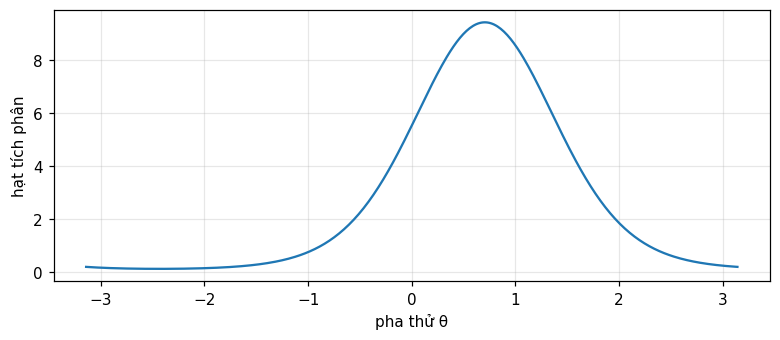

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
thetas_plot = np.linspace(-np.pi, np.pi, 400)
vals_plot = np.exp((2*A/N0b)*(yc*np.cos(thetas_plot) - ys*np.sin(thetas_plot)))
ax.plot(thetas_plot, vals_plot)
ax.set_xlabel(("pha thử θ")); ax.set_ylabel(("hạt tích phân")); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Tích phân trực tiếp 2.7172 khớp hàm Bessel đóng 2.7172.